# IT2011 AI & ML - Multi-Layer Perceptron (MLP)
**Student:** Mahith Menuja (IT25102298)  
**Task:** Binary classification of wine quality (`quality >= 7` -> High) on UCI Wine Quality (red + white).  

In [1]:
# ===== Cell 1: Problem Setup & Data Ingestion =====
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)
from sklearn.neural_network import MLPClassifier
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

STUDENT_ID   = "IT25102298"
STUDENT_NAME = "Mahith Menuja"
MODEL_NAME   = "Multi-Layer Perceptron (MLP)"

# Notebooks live in <project>/notebooks/, so results go to ../results; standalone runs use ./results
RESULTS_DIR = "../results" if os.path.isdir("../data") else "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

UCI_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/"

def load_wine(kind):
    fname = f"winequality-{kind}.csv"
    for d in ["../data/raw", "../data", "data/raw", "data", "."]:
        path = os.path.join(d, fname)
        if os.path.exists(path):
            print(f"Loaded {fname} from {d}/")
            return pd.read_csv(path, sep=";")
    print(f"{fname} not found locally -> downloading from UCI")
    return pd.read_csv(UCI_URL + fname, sep=";")

red, white = load_wine("red"), load_wine("white")
red["wine_type"], white["wine_type"] = 0, 1          # 0 = red, 1 = white
df = pd.concat([red, white], ignore_index=True)
df["target"] = (df["quality"] >= 7).astype(int)       # 1 = high quality

X = df.drop(columns=["quality", "target"])
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Total: {df.shape} | Features: {X.shape[1]}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Class balance (train):", y_train.value_counts(normalize=True).round(3).to_dict())
print("Class balance (test): ", y_test.value_counts(normalize=True).round(3).to_dict())


winequality-red.csv not found locally -> downloading from UCI
winequality-white.csv not found locally -> downloading from UCI
Total: (6497, 14) | Features: 12
Train: (5197, 12), Test: (1300, 12)
Class balance (train): {0: 0.804, 1: 0.196}
Class balance (test):  {0: 0.803, 1: 0.197}


In [2]:
# ===== Cell 2: Feature Transformation & Variety Preprocessing =====
# Fit transformers on TRAIN only (no leakage), then apply to test.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

pca = PCA(n_components=6, random_state=RANDOM_STATE)
X_train_p = pca.fit_transform(X_train_s)
X_test_p  = pca.transform(X_test_s)

print("Standardized features:", X_train_s.shape, "| PCA features:", X_train_p.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))
print(f"Cumulative variance retained by 6 PCs: {pca.explained_variance_ratio_.sum():.3f}")


Standardized features: (5197, 12) | PCA features: (5197, 6)
Explained variance ratio: [0.318 0.211 0.13  0.081 0.06  0.051]
Cumulative variance retained by 6 PCs: 0.852


In [3]:
# ===== Cell 3: Baseline Model Training (default hyperparameters) =====
def get_scores(model, X_):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_)[:, 1]
    return model.decision_function(X_)

def evaluate(model, X_, y_):
    pred, score = model.predict(X_), get_scores(model, X_)
    return {
        "accuracy":    accuracy_score(y_, pred),
        "precision":   precision_score(y_, pred, zero_division=0),   # class 1 (high quality)
        "recall":      recall_score(y_, pred, zero_division=0),      # class 1 (high quality)
        "weighted_f1": f1_score(y_, pred, average="weighted"),
        "macro_f1":    f1_score(y_, pred, average="macro"),
        "roc_auc":     roc_auc_score(y_, score),
    }

baseline_rows = {}
for name, (Xtr, Xte) in {"Standardized": (X_train_s, X_test_s), "PCA-6": (X_train_p, X_test_p)}.items():
    base = MLPClassifier(max_iter=500, random_state=RANDOM_STATE)
    base.fit(Xtr, y_train)
    baseline_rows[name] = evaluate(base, Xte, y_test)

baseline_df = pd.DataFrame(baseline_rows).T.round(4)
print(f"BASELINE ({MODEL_NAME}, default hyperparameters) - test set")
print(baseline_df[["accuracy", "weighted_f1", "roc_auc"]])
baseline_metrics = baseline_rows["Standardized"]


BASELINE (Multi-Layer Perceptron (MLP), default hyperparameters) - test set
              accuracy  weighted_f1  roc_auc
Standardized    0.8377       0.8255   0.8642
PCA-6           0.8415       0.8192   0.8399


In [4]:
# ===== Cell 4: Systematic Hyperparameter Tuning (GridSearchCV) =====
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    "hidden_layer_sizes": [(64,), (128, 64), (64, 32, 16)],
    "activation": ["relu", "tanh"],
    "alpha": [1e-4, 1e-3, 1e-2],
    "learning_rate_init": [1e-3, 1e-2],
}

feature_sets = {
    "Standardized (12 features)": (X_train_s, X_test_s),
    "PCA (6 components)":         (X_train_p, X_test_p),
}

search_results = {}
for fs_name, (Xtr, Xte) in feature_sets.items():
    gs = GridSearchCV(MLPClassifier(max_iter=500, early_stopping=True, n_iter_no_change=15, random_state=RANDOM_STATE), param_grid, cv=cv,
                      scoring="f1_weighted", n_jobs=-1, refit=True)
    gs.fit(Xtr, y_train)
    search_results[fs_name] = {"search": gs, "test": evaluate(gs.best_estimator_, Xte, y_test)}
    print(f"[{fs_name}] best CV weighted-F1 = {gs.best_score_:.4f} | params = {gs.best_params_}")

variety_df = pd.DataFrame({
    fs: {"cv_weighted_f1": r["search"].best_score_, **r["test"]}
    for fs, r in search_results.items()
}).T.round(4)
print("\nFEATURE VARIETY COMPARISON (tuned model)")
print(variety_df)

# Choose the feature set using CROSS-VALIDATION score only (never the test set)
best_fs      = max(search_results, key=lambda k: search_results[k]["search"].best_score_)
best_search  = search_results[best_fs]["search"]
best_model   = best_search.best_estimator_
X_test_best  = feature_sets[best_fs][1]
print(f"\nSelected feature set: {best_fs}")


[Standardized (12 features)] best CV weighted-F1 = 0.8238 | params = {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (64, 32, 16), 'learning_rate_init': 0.01}
[PCA (6 components)] best CV weighted-F1 = 0.8249 | params = {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (64, 32, 16), 'learning_rate_init': 0.01}

FEATURE VARIETY COMPARISON (tuned model)
                            cv_weighted_f1  accuracy  precision  recall  \
Standardized (12 features)          0.8238    0.8369     0.6209  0.4414   
PCA (6 components)                  0.8249    0.8238     0.5659  0.4531   

                            weighted_f1  macro_f1  roc_auc  
Standardized (12 features)       0.8259    0.7090   0.8594  
PCA (6 components)               0.8162    0.6981   0.8430  

Selected feature set: PCA (6 components)


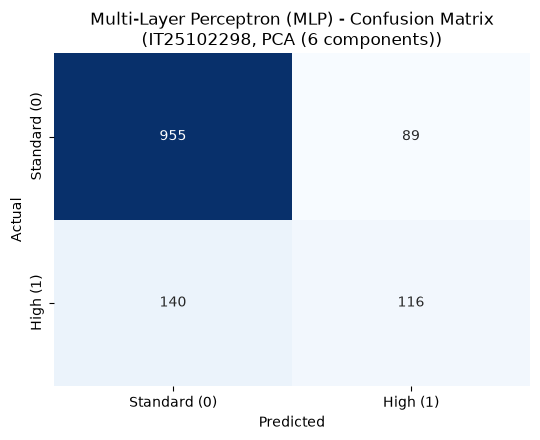

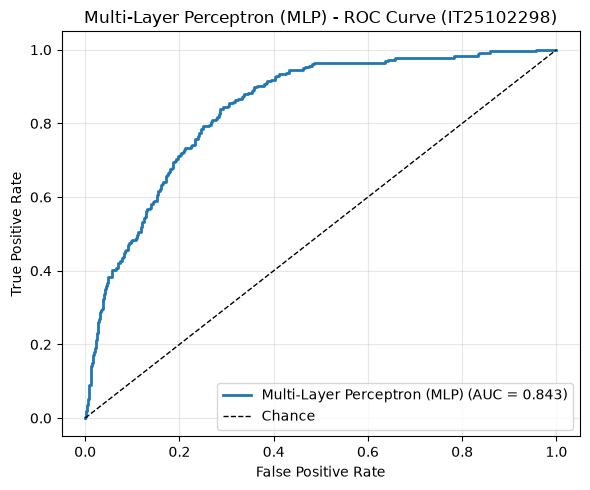

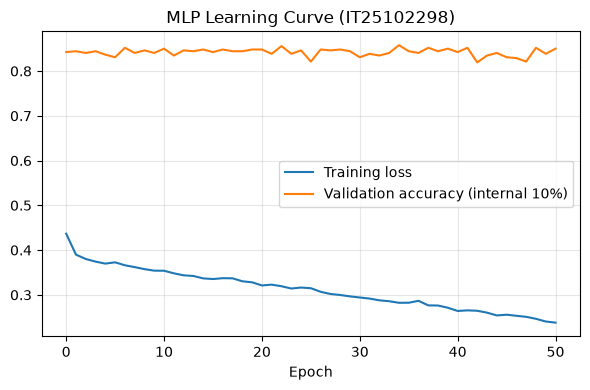

              precision    recall  f1-score   support

Standard (0)     0.8721    0.9148    0.8929      1044
    High (1)     0.5659    0.4531    0.5033       256

    accuracy                         0.8238      1300
   macro avg     0.7190    0.6839    0.6981      1300
weighted avg     0.8118    0.8238    0.8162      1300

Saved: results/IT25102298_metrics.json


In [5]:
# ===== Cell 5: Visual Diagnostics & JSON Metrics Export =====
y_pred  = best_model.predict(X_test_best)
y_score = get_scores(best_model, X_test_best)
final   = evaluate(best_model, X_test_best, y_test)

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Standard (0)", "High (1)"], yticklabels=["Standard (0)", "High (1)"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"{MODEL_NAME} - Confusion Matrix\n({STUDENT_ID}, {best_fs})")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/{STUDENT_ID}_cm.png", dpi=300, bbox_inches="tight")
plt.show()

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f"{MODEL_NAME} (AUC = {final['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"{MODEL_NAME} - ROC Curve ({STUDENT_ID})")
plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/{STUDENT_ID}_roc.png", dpi=300, bbox_inches="tight")
plt.show()

# --- MLP-specific: training loss curve of the selected network ---
plt.figure(figsize=(6, 4))
plt.plot(best_model.loss_curve_, label="Training loss")
if getattr(best_model, "validation_scores_", None) is not None:
    plt.plot(best_model.validation_scores_, label="Validation accuracy (internal 10%)")
plt.xlabel("Epoch"); plt.title(f"MLP Learning Curve ({STUDENT_ID})")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/{STUDENT_ID}_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Classification report ---
print(classification_report(y_test, y_pred, target_names=["Standard (0)", "High (1)"], digits=4))

# --- JSON export (ROC curve is resampled to 200 points so the group notebook can overlay it) ---
grid_fpr = np.linspace(0, 1, 200)
grid_tpr = np.interp(grid_fpr, fpr, tpr)

metrics = {
    "student_id": STUDENT_ID,
    "student_name": STUDENT_NAME,
    "model": MODEL_NAME,
    "feature_set": best_fs,
    "best_params": best_search.best_params_,
    "cv_weighted_f1": float(best_search.best_score_),
    "accuracy": float(final["accuracy"]),
    "precision": float(final["precision"]),
    "recall": float(final["recall"]),
    "weighted_f1": float(final["weighted_f1"]),
    "macro_f1": float(final["macro_f1"]),
    "roc_auc": float(final["roc_auc"]),
    "baseline": {k: float(v) for k, v in baseline_metrics.items()},
    "variety": {fs: {k: float(v) for k, v in row.items()} for fs, row in variety_df.to_dict("index").items()},
    "confusion_matrix": cm.tolist(),
    "roc_curve": {"fpr": grid_fpr.round(5).tolist(), "tpr": grid_tpr.round(5).tolist()},
}
with open(f"{RESULTS_DIR}/{STUDENT_ID}_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, default=str)
print(f"Saved: {RESULTS_DIR}/{STUDENT_ID}_metrics.json")
